Author: Sofia Midauar

Date: April 2023

In [2]:
# !pip install geopandas
# !pip install country_converter

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib import rc
import time
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec

In [4]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
# Import files
review_complete = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/PhD/review/files/database_papers_updated_format.xlsx')

review_complete.head()

,id,authors,DOI,citations,year,publication_type,review,evidence_type,system,hemisphere,country,latitude_N,longitude_E,climate_zone,thermal_region,site,waterbody_type,water_type,hydropower,surface_area_km2,capacity_hm3,max_depth,mean_depth,thermal_structure,trophic_state,site_quantity,with_without_fpv,bef_after_deploym,climate_period,climate_source,climate_frequency,wq_field_period,multiple_seasons,time_bef_fpv_months,sample_freq_days,multiple_samp_points,depth_resolved,fpv_design,fpv_capacity_MWhyear,fpv_const_material,water_body_location,floater_type,fpv_area_km2,fpv_coverage,variables_radiation,variables_evap,variable_conductivity,variable_salinity,variable_Ph,variable_DO,variable_temperature,variable_oxidation-reduction-potential,variables_stratification,variable_light_transp,variable_sedimentressusp,variable_suspendedsolids,variable_plankton,variable_nutrient,variable_TDS,variable_TOC,variable_BOD,variable_TPI,variable_contaminant,variable_fish,water_saving_hm3year,water_saving_record,evap_mmday,evap_record,conductivity_µs-cm,conductivity_record,salinity_ppt,salinity_record,pH,pH_record,alkalinity_meq-L,alkalinity_record,DO_mg-L,DO_record,surface_temp,surface_temp_record,bottom_temp,bottom_temp_record,ORP_mV,ORP_record,stratification_duration_day,strat_duration_record,strat_strength_degC,strat_strength_record,termocline_depth_m,temocline_depth_record,secchi_depth_m,secchi_record,light_intens_lux,light_intens_record,susp_solids_mg-L,susp_solids_record,plankton_μg-L,plankton_record,plankton_biomass_unit-L,plankton_biomass_record,plankton_comm_diversity,plankton_comm_diversity_record,PO4_mg-L,PO4_record,organic_P_μg-L,organic_P_record,TP_mg-L,TP_record,TN_mg-L,TN_record,nitrogen_mg-L,nitrogen_record,organic_N_μg-L,organic_N_record,NH3_mg-L,NH3_record,nitrate_nitrogen_mg-L,nitrate_nitrogen_record,NO2_mg-L,NO2_record,total_ammonia_N_ppm,total_ammonia_N_record,TDS_ppt,TDS_record,TOC_mg-L,TOC_record,BOD_mg-L,BOD_record,TPI_ppm,TPI_record,aquatic_plants,aquatic_plants_record,contaminant_mg-L,contaminant_record,ice_cover_duration_day,ice_cov_dur_record,fish_appetite_g-ind,fish_appetite_record,fish_production_kg-acre,fish_produc_record,fish_growth,fish_growth_record,societal_impacts,societal_impacts_surveys,societal_impacts_direction
0,1 Abd-Elhamid et al. 2021,"Hany F. Abd-Elhamid 1,2, Ashraf Ahmed 3, Marti...",10.3390/w13060769,7,2021.0,Journal,No,Modelled,Macrocosm,Northern,Egypt,22,32,BWh,NH,Lake Nasser,Dammed,Freshwater,No,6500.000000,162000.000000,-,-,NaN,NaN,1.0,NaN,No,2009 - 2020,Other,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850000000,NaN,NaN,NaN,1625,0.25,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2100,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5700000000,NaN,NaN,NaN,3250,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4201,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8550000000.000001,NaN,NaN,NaN,4875,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6302,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
# Create subset with one row per paper
review_papers = review_complete[review_complete['id'].notna()] # excludes rows with NA values in ID column
review_papers
# review_papers.head()

,id,authors,DOI,citations,year,publication_type,review,evidence_type,system,hemisphere,country,latitude_N,longitude_E,climate_zone,thermal_region,site,waterbody_type,water_type,hydropower,surface_area_km2,capacity_hm3,max_depth,mean_depth,thermal_structure,trophic_state,site_quantity,with_without_fpv,bef_after_deploym,climate_period,climate_source,climate_frequency,wq_field_period,multiple_seasons,time_bef_fpv_months,sample_freq_days,multiple_samp_points,depth_resolved,fpv_design,fpv_capacity_MWhyear,fpv_const_material,water_body_location,floater_type,fpv_area_km2,fpv_coverage,variables_radiation,variables_evap,variable_conductivity,variable_salinity,variable_Ph,variable_DO,variable_temperature,variable_oxidation-reduction-potential,variables_stratification,variable_light_transp,variable_sedimentressusp,variable_suspendedsolids,variable_plankton,variable_nutrient,variable_TDS,variable_TOC,variable_BOD,variable_TPI,variable_contaminant,variable_fish,water_saving_hm3year,water_saving_record,evap_mmday,evap_record,conductivity_µs-cm,conductivity_record,salinity_ppt,salinity_record,pH,pH_record,alkalinity_meq-L,alkalinity_record,DO_mg-L,DO_record,surface_temp,surface_temp_record,bottom_temp,bottom_temp_record,ORP_mV,ORP_record,stratification_duration_day,strat_duration_record,strat_strength_degC,strat_strength_record,termocline_depth_m,temocline_depth_record,secchi_depth_m,secchi_record,light_intens_lux,light_intens_record,susp_solids_mg-L,susp_solids_record,plankton_μg-L,plankton_record,plankton_biomass_unit-L,plankton_biomass_record,plankton_comm_diversity,plankton_comm_diversity_record,PO4_mg-L,PO4_record,organic_P_μg-L,organic_P_record,TP_mg-L,TP_record,TN_mg-L,TN_record,nitrogen_mg-L,nitrogen_record,organic_N_μg-L,organic_N_record,NH3_mg-L,NH3_record,nitrate_nitrogen_mg-L,nitrate_nitrogen_record,NO2_mg-L,NO2_record,total_ammonia_N_ppm,total_ammonia_N_record,TDS_ppt,TDS_record,TOC_mg-L,TOC_record,BOD_mg-L,BOD_record,TPI_ppm,TPI_record,aquatic_plants,aquatic_plants_record,contaminant_mg-L,contaminant_record,ice_cover_duration_day,ice_cov_dur_record,fish_appetite_g-ind,fish_appetite_record,fish_production_kg-acre,fish_produc_record,fish_growth,fish_growth_record,societal_impacts,societal_impacts_surveys,societal_impacts_direction
0,1 Abd-Elhamid et al. 2021,"Hany F. Abd-Elhamid 1,2, Ashraf Ahmed 3, Marti...",10.3390/w13060769,7,2021.0,Journal,No,Modelled,Macrocosm,Northern,Egypt,22,32,BWh,NH,Lake Nasser,Dammed,Freshwater,No,6500.000000,162000.000000,-,-,NaN,NaN,1.0,NaN,No,2009 - 2020,Other,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850000000,NaN,NaN,NaN,1625,0.25,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2100,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
4,2 Abdelal 2021,Qasem Abdelal,https://doi.org/10.1093/ijlct/ctab001,10,2021.0,Journal,No,Empirical,Microcosm,Middle east,Jordan,31.78,35.8,BWh,NH,Pilot study tank,Tank,Freshwater,No,0.000004,0.000004,1,1,NaN,NaN,2.0,Yes,No,Aug-Nov 2018,Weather station,Continuous,NaN,No,1.0,7,No,Yes,NaN,NaN,Mono and Polycrystalline,NaN,NaN,0.000004,1,No,Yes,No,No,No,No,Yes,No,Yes,No,No,No,Yes,Yes,No,No,No,No,No,No,NaN,NaN,1.08,Decrease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Decrease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Decrease,NaN,NaN,NaN,NaN,NaN,Decrease,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
6,3 Abid et al. 2019,"M. Abid, Z. Abid, J. Sagin, R. Murtaza, D. Sa...",https://doi.org/10.1007/s13762-018-2080-5,28,2019.0,Journal,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [7]:
# Check distribution of number of citations per publication
# review_papers['citations'].hist()

# Subset of database: review papers excluded

In [8]:
# Create subset without review papers
db_noreviews = review_complete[(review_complete['review'] != 'Yes') & (review_complete['publication_type'] != 'Book chapter')]
db_noreviews.head()

,id,authors,DOI,citations,year,publication_type,review,evidence_type,system,hemisphere,country,latitude_N,longitude_E,climate_zone,thermal_region,site,waterbody_type,water_type,hydropower,surface_area_km2,capacity_hm3,max_depth,mean_depth,thermal_structure,trophic_state,site_quantity,with_without_fpv,bef_after_deploym,climate_period,climate_source,climate_frequency,wq_field_period,multiple_seasons,time_bef_fpv_months,sample_freq_days,multiple_samp_points,depth_resolved,fpv_design,fpv_capacity_MWhyear,fpv_const_material,water_body_location,floater_type,fpv_area_km2,fpv_coverage,variables_radiation,variables_evap,variable_conductivity,variable_salinity,variable_Ph,variable_DO,variable_temperature,variable_oxidation-reduction-potential,variables_stratification,variable_light_transp,variable_sedimentressusp,variable_suspendedsolids,variable_plankton,variable_nutrient,variable_TDS,variable_TOC,variable_BOD,variable_TPI,variable_contaminant,variable_fish,water_saving_hm3year,water_saving_record,evap_mmday,evap_record,conductivity_µs-cm,conductivity_record,salinity_ppt,salinity_record,pH,pH_record,alkalinity_meq-L,alkalinity_record,DO_mg-L,DO_record,surface_temp,surface_temp_record,bottom_temp,bottom_temp_record,ORP_mV,ORP_record,stratification_duration_day,strat_duration_record,strat_strength_degC,strat_strength_record,termocline_depth_m,temocline_depth_record,secchi_depth_m,secchi_record,light_intens_lux,light_intens_record,susp_solids_mg-L,susp_solids_record,plankton_μg-L,plankton_record,plankton_biomass_unit-L,plankton_biomass_record,plankton_comm_diversity,plankton_comm_diversity_record,PO4_mg-L,PO4_record,organic_P_μg-L,organic_P_record,TP_mg-L,TP_record,TN_mg-L,TN_record,nitrogen_mg-L,nitrogen_record,organic_N_μg-L,organic_N_record,NH3_mg-L,NH3_record,nitrate_nitrogen_mg-L,nitrate_nitrogen_record,NO2_mg-L,NO2_record,total_ammonia_N_ppm,total_ammonia_N_record,TDS_ppt,TDS_record,TOC_mg-L,TOC_record,BOD_mg-L,BOD_record,TPI_ppm,TPI_record,aquatic_plants,aquatic_plants_record,contaminant_mg-L,contaminant_record,ice_cover_duration_day,ice_cov_dur_record,fish_appetite_g-ind,fish_appetite_record,fish_production_kg-acre,fish_produc_record,fish_growth,fish_growth_record,societal_impacts,societal_impacts_surveys,societal_impacts_direction
0,1 Abd-Elhamid et al. 2021,"Hany F. Abd-Elhamid 1,2, Ashraf Ahmed 3, Marti...",10.3390/w13060769,7,2021.0,Journal,No,Modelled,Macrocosm,Northern,Egypt,22,32,BWh,NH,Lake Nasser,Dammed,Freshwater,No,6500.000000,162000.000000,-,-,NaN,NaN,1.0,NaN,No,2009 - 2020,Other,Monthly,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2850000000,NaN,NaN,NaN,1625,0.25,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2100,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5700000000,NaN,NaN,NaN,3250,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4201,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8550000000.000001,NaN,NaN,NaN,4875,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6302,Increase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [9]:
lakes_coords = db_noreviews[['id', 'evidence_type', 'country', 'latitude_N', 'longitude_E']]
lakes_coords.dropna(inplace = True)
# lakes_coords = lakes_coords[(lakes_coords['evidence_type'] != 'Modelled') & (lakes_coords['latitude_N'] != 'varies')]
lakes_coords = lakes_coords[(lakes_coords['latitude_N'] != 'varies') & (lakes_coords['latitude_N'] != 'Multiple')]
lakes_coords

<ipython-input-9-d17751cc592d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lakes_coords.dropna(inplace = True)


,id,evidence_type,country,latitude_N,longitude_E
0,1 Abd-Elhamid et al. 2021,Modelled,Egypt,22,32
4,2 Abdelal 2021,Empirical,Jordan,31.78,35.8
7,5 Agrawal et al. 2022,Modelled,India,24.73,78.22
8,6 Al-Widyan et al. 2021,Empirical,Jordan,32.49,35.98
12,7 Andini et al. 2022,Empirical,Indonesia,-6.36,106.83
22,12 Scavo et al. 2019,Modelled,Italy,37.323,14.95
29,14 Château et al. 2019,Empirical,Taiwan,23.32912,119.8713
32,16 da Costa and da Silva 2021,Modelled,Brazil,8.516111,39.26465
34,19 de Campos et al. 2021,Modelled,Brazil,-9.425553,-40.82447
38,22 dos Santos et al. 2022,Modelled,Brazil,-25.5125,-49.36861


In [ ]:
lakes_coords.to_csv('lakes_coords.csv')

In [10]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame

geometry = [Point(xy) for xy in zip(lakes_coords['longitude_E'], lakes_coords['latitude_N'])]
gdf = GeoDataFrame(lakes_coords, geometry=geometry)

#this is a simple map that goes with geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='k', markersize=15);

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

# Barplot of publications per year and reviews

In [11]:
# Get number of publications per year
years = review_papers['year'].value_counts()
years = pd.DataFrame(years)
years = years.reset_index()
years.rename(columns = {'year':'years'}, inplace = True)
years = years.sort_values(by = ['years'])
years['years'] = years['years'].astype(int)

# Add info: which of those are reviews?
year_review = years['years']
reviews = [0,1,1,1,2,1,4,3,0,0] # manually estimated in excel
years['reviews'] = reviews

# Add 2015
new_row = {'years':2015, 'count':0, 'reviews':0}
years.loc[len(years)] = new_row
years = years.sort_values(by = ['years'])

# Add column with cumulative sum
years['count_cum_sum'] = years['count'].cumsum()

years

,years,count,reviews,count_cum_sum
9,2014,1,0,1
10,2015,0,0,1
7,2016,3,1,4
8,2017,2,1,6
6,2018,3,1,9
4,2019,8,2,17
3,2020,12,1,29
0,2021,23,4,52
2,2022,14,3,66
1,2023,18,0,84


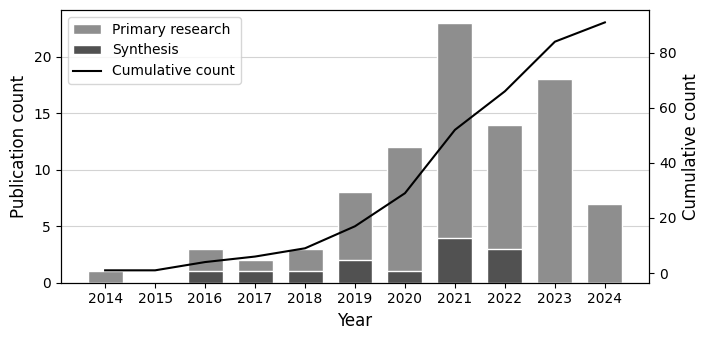

In [ ]:
# barplot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[7.2,3.5])

# plot
barWidth = 0.7

ax.bar(years['years'], years['count'], color='#8E8E8E', edgecolor='white', width=barWidth, label = 'Primary research')
ax.bar(years['years'], years['reviews'], color='#515151', edgecolor='white', width=barWidth, label = 'Synthesis')

ax2 = ax.twinx()

ax2.plot(years['years'], years['count_cum_sum'], color='k', label = "Cumulative count")
ax2.set_ylabel("Cumulative count", size = 12)

xlabels = years['years']
ax.set_xticks(years['years'])
ax.set_xticklabels(years['years'])
ax.set_ylabel("Publication count", size = 12)
ax.set_xlabel("Year", size = 12)
# ax.legend(loc = 'upper left')

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

# Plot adjustments
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

plt.tight_layout()

# Save graph
plt.savefig('publications_yearly_distribution_updated.jpg', format = 'jpeg', dpi=300);

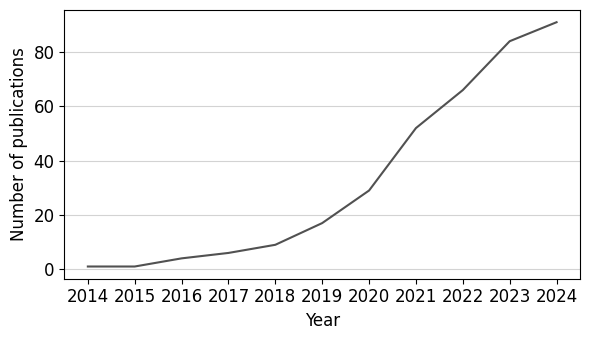

In [ ]:
# barplot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[6,3.5])

# plot
barWidth = 0.7

ax.plot(years['years'], years['count_cum_sum'], color='#515151')

xlabels = years['years']
ax.set_xticks(years['years'])
ax.set_xticklabels(years['years'])
ax.set_ylabel("Number of publications", size = 12)
ax.set_xlabel("Year", size = 12)

ax.set_axisbelow(True)
ax.grid(color='lightgray', axis = 'y')

# Plot adjustments
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

plt.tight_layout()

# Save graph
# plt.savefig('cumulative_plot_publications.png', format = 'png', dpi=300);

# Percentage of review papers

In [12]:
# Get number of publications per year
perc_review = review_papers['review'].value_counts()
perc_review = pd.DataFrame(perc_review)
perc_review = perc_review.reset_index()
# perc_review.rename(columns = {'index':'review', 'review':'count'}, inplace = True)
perc_review

,review,count
0,No,74
1,Yes,17


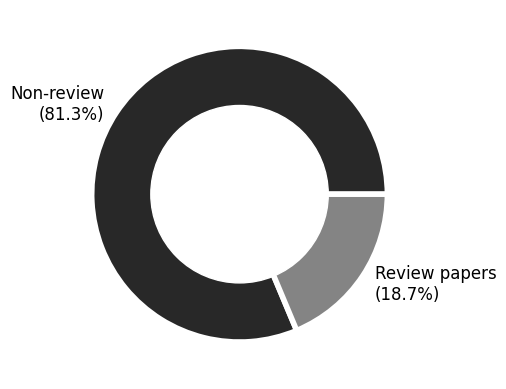

In [ ]:
# Create a circle at the center of the plot
# plt.switch_backend('agg') # line to export figure
fig, ax = plt.subplots()
pub_type_circle = plt.Circle((0,0), 0.6, color='white')

# Give color names
labels = ['Non-review', 'Review papers']
sizes = perc_review['count']

pcts = [f'{l}\n({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(perc_review['count'], labels = pcts, labeldistance = 1.1, colors = ['#282828','#848484','#C0C0C0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(pub_type_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_perc_review.png', format = 'png', dpi=300);

# Plot of publications per type - missing export figure

In [13]:
# Get number of publications per year
pub_type = review_papers['publication_type'].value_counts()
pub_type = pd.DataFrame(pub_type)
pub_type = pub_type.reset_index()
pub_type.rename(columns = {'publication_type':'Publication Type'}, inplace = True)
pub_type

,Publication Type,count
0,Journal,78
1,Conference,11
2,Book chapter,2


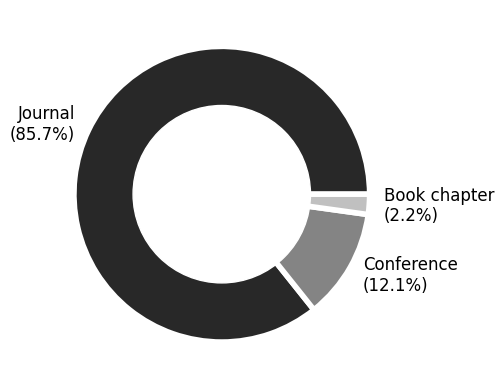

In [ ]:
# Create a circle at the center of the plot
fig, ax = plt.subplots()
pub_type_circle = plt.Circle((0,0), 0.6, color='white')

# Give color names
labels = pub_type['Publication Type']
sizes = pub_type['count']

pcts = [f'{l}\n({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(pub_type['count'], labels = pcts, labeldistance = 1.1, colors = ['#282828','#848484','#C0C0C0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(pub_type_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_pub_type.png', format = 'png', dpi=300);

# Plot of publications per evidence type - missing export figure

In [14]:
# Get number of publications per year
evidence_type = db_noreviews['evidence_type'].value_counts()
evidence_type = pd.DataFrame(evidence_type)
evidence_type = evidence_type.reset_index()
evidence_type.rename(columns = {'evidence_type':'Evidence Type'}, inplace = True)
evidence_type

,Evidence Type,count
0,Modelled,49
1,Empirical,20
2,Both,3


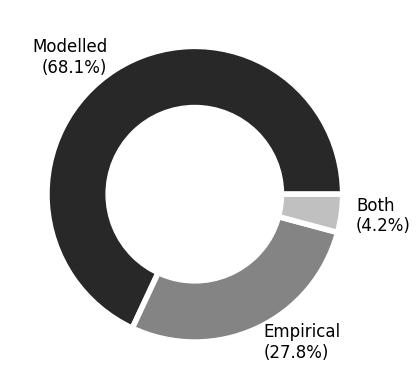

In [ ]:
# Create a circle at the center of the plot
fig, ax = plt.subplots()
evidence_type_circle = plt.Circle((0,0), 0.6, color='white')

# Give color names
labels = evidence_type['Evidence Type']
sizes = evidence_type['count']

pcts = [f'{l}\n({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(evidence_type['count'], labels = pcts, labeldistance = 1.1, colors = ['#282828','#848484','#C0C0C0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(evidence_type_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_evidence_type.png', format = 'png', dpi=300);

# Barplot of climate regions

In [15]:
climate_zone = db_noreviews['climate_zone'].value_counts()
climate_zone = pd.DataFrame(climate_zone)
climate_zone = climate_zone.reset_index()

climate_zone

,climate_zone,count
0,Cfb,12
1,Csa,11
2,BWh,10
3,Aw,5
4,Af,4
5,Cwa,4
6,BSh,3
7,Csb,2
8,BSk,2
9,BWk,2


In [16]:
# Get number of climate zones
climate_zone = db_noreviews['climate_zone'].value_counts()
climate_zone = pd.DataFrame(climate_zone)
climate_zone = climate_zone.reset_index()
# climate_zone.rename(columns = {'index':'climate_zone', 'climate_zone':'count'}, inplace = True)

# Get number of lake thermal regions
thermal_region = db_noreviews['thermal_region'].value_counts()
thermal_region = pd.DataFrame(thermal_region)
thermal_region = thermal_region.reset_index()
# thermal_region.rename(columns = {'index':'thermal_region', 'thermal_region':'count'}, inplace = True)
thermal_region

,thermal_region,count
0,NW,18
1,NH,14
2,TH,10
3,NT,6
4,SH,3
5,ST,1


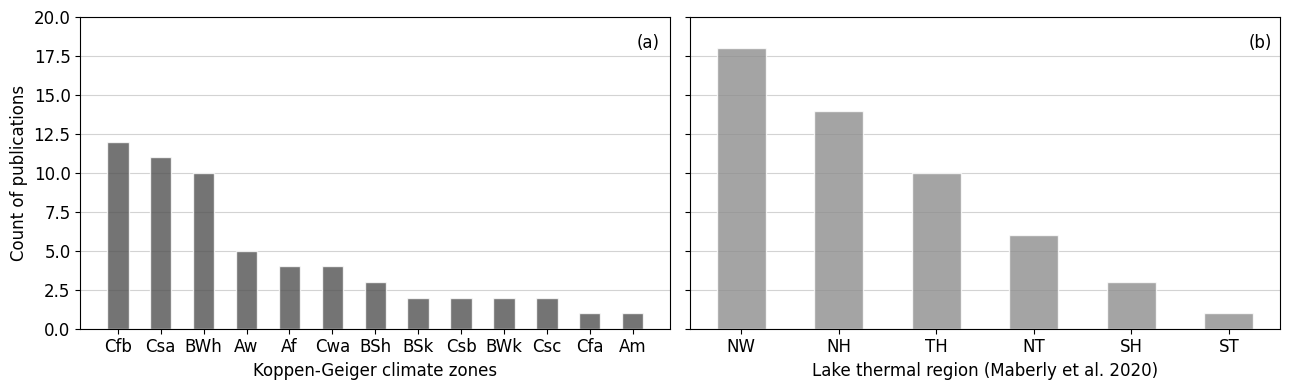

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 4), sharey = True)
barWidth = 0.5

# Climate zone
ax[0].bar(climate_zone['climate_zone'], climate_zone['count'], color='#515151', edgecolor='white', width = barWidth, alpha = 0.8)
# ax[0].hist(climate_zone['climate_zone'], edgecolor="black", color="#282828", align = 'mid' , alpha = 0.8)

ax[0].set_ylabel("Count of publications", size = 12)
ax[0].set_xlabel("Koppen-Geiger climate zones", size = 12)
ax[0].set_ylim(0,20)

ax[0].set_axisbelow(True)
ax[0].grid(color='lightgray', axis = 'y')

ax[0].text(12.1, 18, '(a)', color = 'k', size = 12)

# Lake thermal region
ax[1].bar(thermal_region['thermal_region'], thermal_region['count'], color='#8E8E8E', edgecolor='white', width = barWidth, alpha = 0.8)

ax[1].set_xlabel("Lake thermal region (Maberly et al. 2020)", size = 12)
# ax[1].set_ylim(0,16)

ax[1].set_axisbelow(True)
ax[1].grid(color='lightgray', axis = 'y')

ax[1].text(5.2, 18, '(b)', color = 'k', size = 12)

# Plot adjustments
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.tight_layout()

# Save graph
plt.savefig('bar_zones_updated_search.jpeg', format = 'jpeg', dpi=300);

# Water body type

In [ ]:
# Get distribution of studies per water body type
wb_type = db_noreviews['waterbody_type'].value_counts()
wb_type = pd.DataFrame(wb_type)
wb_type = wb_type.reset_index()
wb_type.rename(columns = {'waterbody_type':'wb_type'}, inplace = True)
wb_type

,wb_type,count
0,Dammed,48
1,Tank,7
2,Fish pond,6
3,Natural,4
4,Mining pit,3
5,Canal,2
6,Irrigation,2
7,Lab scale,1
8,Wastewater pond,1
9,Gravel pit,1


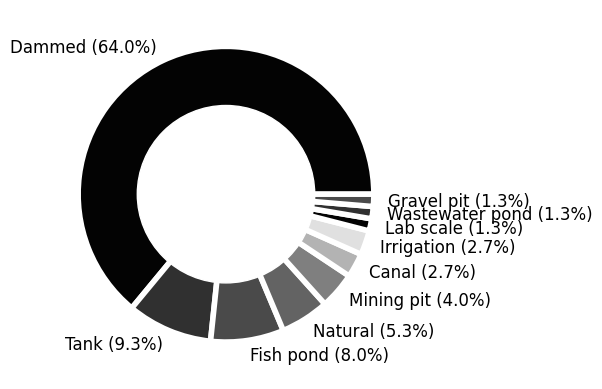

In [ ]:
# Create a circle at the center of the plot
# plt.switch_backend('agg') # line to export figure
fig, ax = plt.subplots()
wb_type_circle = plt.Circle((0,0), 0.6, color='white')

# Give color names
labels = wb_type['wb_type']
sizes = wb_type['count']

pcts = [f'{l} ({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(wb_type['count'], labels = pcts, labeldistance = 1.1, colors = ['#030303','#303030','#4A4A4A','#636363','#7F7F7F','#B3B3B3','#E0E0E0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(wb_type_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_wb_type.png', format = 'png', dpi=300);

# Hydropower

In [ ]:
# Get distribution of studies per water body type
hydro_papers = db_noreviews['hydropower'].value_counts()
hydro_papers = pd.DataFrame(hydro_papers)
hydro_papers = hydro_papers.reset_index()
# hydro_papers.rename(columns = {'index':'hydropower', 'hydropower':'count'}, inplace = True)
hydro_papers

,hydropower,count
0,No,47
1,Yes,29


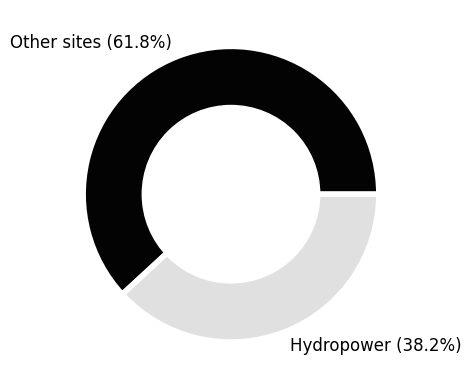

In [ ]:
# Create a circle at the center of the plot
fig, ax = plt.subplots()
hydropower_circle = plt.Circle((0,0), 0.6, color='white')

# Give color names
labels = ['Other sites','Hydropower']
sizes = hydro_papers['count']

pcts = [f'{l} ({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(hydro_papers['count'], labels = pcts, labeldistance = 1.1, colors = ['#030303', '#E0E0E0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(hydropower_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_hydropower.png', format = 'png', dpi=300);

In [ ]:
reviews = sum(review_complete['review'] == 'No')
reviews

74

# FPV - comparison with x without and before x after

In [ ]:
## Get distribution of studies that have comparison with and without FPV + before and after deployment
# With x without
fpv_comparison = db_noreviews['with_without_fpv'].value_counts()
fpv_comparison = pd.DataFrame(fpv_comparison)
fpv_comparison = fpv_comparison.reset_index()
fpv_comparison.rename(columns = {'with_without_fpv':'fpv_comparison'}, inplace = True)

# Before x after deployment
fpv_bef_after = db_noreviews['bef_after_deploym'].value_counts()
fpv_bef_after = pd.DataFrame(fpv_bef_after)
fpv_bef_after = fpv_bef_after.reset_index()
fpv_bef_after.rename(columns = {'bef_after_deploym':'fpv_bef_after'}, inplace = True)
fpv_bef_after

,fpv_bef_after,count
0,No,54
1,Yes,8


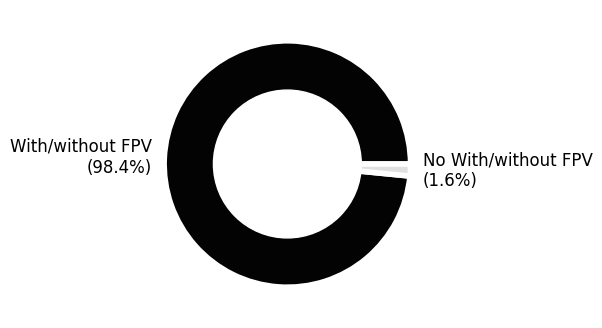

In [ ]:
# Create a circle at the center of the plot
fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (6,4))
fpv_circle = plt.Circle((0,0), 0.6, color='white')

# With x without FPV
labels = ['With/without FPV','No With/without FPV']
sizes = fpv_comparison['count']

pcts = [f'{l}\n({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(fpv_comparison['count'], labels = pcts, labeldistance = 1.1, colors = ['#030303', '#E0E0E0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(fpv_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_fpv_with_without.png', format = 'png', dpi=300);

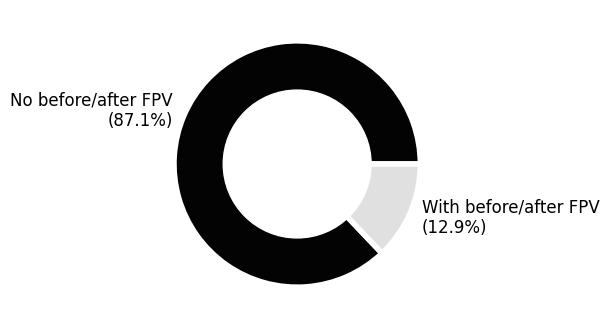

In [ ]:
# Create a circle at the center of the plot
fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (6,4))
fpv_circle = plt.Circle((0,0), 0.6, color='white')

# Before x after deployment
labels = ['No before/after FPV', 'With before/after FPV']
sizes = fpv_bef_after['count']

pcts = [f'{l}\n({s*100/sum(sizes):.1f}%)' for s,l in zip(sizes, labels)]

ax.pie(fpv_bef_after['count'], labels = pcts, labeldistance = 1.1, colors = ['#030303', '#E0E0E0'], wedgeprops = {'linewidth' : 4, 'edgecolor' : 'white'})
p = plt.gcf()
p.gca().add_artist(fpv_circle)

# Show the graph
plt.show()

# Save graph
# plt.savefig('donut_fpv_bef_after.png', format = 'png', dpi=300);

# Map with number of researches per country

In [ ]:
# Get the unique countries and how many times they are on the table (i.e. how many studies per country)
countries = db_noreviews.country.value_counts()
countries = pd.DataFrame(countries)
countries = countries.reset_index()
# countries.rename(columns = {'count':'country', 'country':'count'}, inplace = True)

# Change USA for United States
countries['country'] = np.where(countries['country'] == 'USA', 'United States of America', countries['country'])
countries.head()

,country,count
0,China,9
1,India,7
2,Egypt,6
3,Brazil,5
4,Italy,4


In [ ]:
countries.to_csv('countries.csv')

In [ ]:
countries['country'].unique()

array(['China', 'India', 'Egypt', 'Brazil', 'Italy',
       'United States of America', 'Taiwan', 'Iran', 'Turkey',
       'Netherlands', 'Singapore', 'Jordan', 'Indonesia', 'England',
       'Multiple', 'Ethiopia', 'Serbia', 'Ghana', 'Spain', 'Afghanistan',
       'Phillipines', 'Thailand', 'Africa', 'Romania', 'Israel', 'Chile',
       'Germany'], dtype=object)

In [ ]:
## Read the world's shapefile
# Setting the path to the shapefile
SHAPEFILE = '/content/drive/MyDrive/Colab Notebooks/PhD/Hydropower/shape_countries/ne_10m_admin_0_countries.shp'

# Read shapefile using Geopandas
geo_df = gpd.read_file(SHAPEFILE)[['ADMIN', 'ADM0_A3', 'geometry']]

# Rename columns.
geo_df.columns = ['country', 'country_code', 'geometry']

# Drop row for 'Antarctica'. It takes a lot of space in the map and is not of much use
geo_df = geo_df.drop(geo_df.loc[geo_df['country'] == 'Antarctica'].index)

geo_df.head(3)

,country,country_code,geometry
0,Indonesia,IDN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Malaysia,MYS,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Chile,CHL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."


In [ ]:
# Prepare dataframe to plot
# Define dataframes for vertical lookup (df1 will be kept the rows, while df2 will be looked for the df1's values, i.e. search df1 country on the df2 list to get the count)
df1 = geo_df
df2 = countries

Left_join = pd.merge(df1, df2, on ='country', how ='left')
Left_join.head()

,country,country_code,geometry,count
0,Indonesia,IDN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...",2.0
1,Malaysia,MYS,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...",NaN
2,Chile,CHL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",1.0
3,Bolivia,BOL,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",NaN
4,Peru,PER,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",NaN


In [ ]:
Left_join['count'].max()

9.0

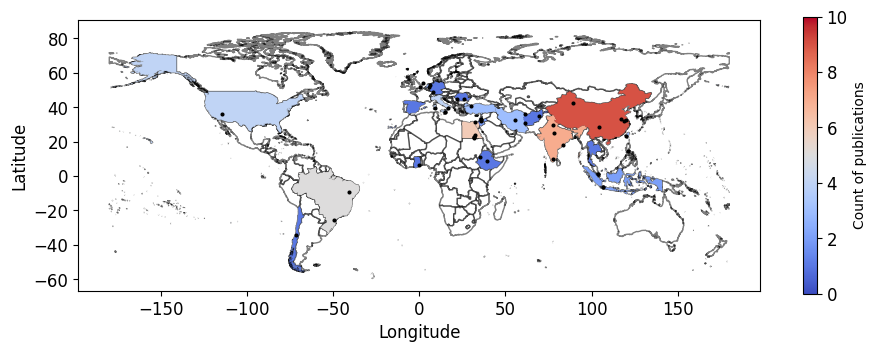

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the country boundaries and the heatmap
# plt.switch_backend('agg') # line to export figure
ax = geo_df.plot(figsize = (11, 8), alpha = 0.5, edgecolor = 'k', facecolor = 'white')
Left_join.plot(ax = ax, markersize = 10, legend = True, vmax = 10, vmin = 0, column = 'count', cmap = 'coolwarm', legend_kwds = {'shrink': 0.45, 'label':'Count of publications'})

# ax.grid(True, linestyle = '-', linewidth = 0.5, color='gray', zorder = -1)

geometry = [Point(xy) for xy in zip(lakes_coords['longitude_E'], lakes_coords['latitude_N'])]
coords_sites = GeoDataFrame(lakes_coords, geometry=geometry)
coords_sites.plot(ax = ax, marker = '.', color = 'k', markersize=15);

# Customize the axis labels
ax.set_facecolor('white')
ax.tick_params(axis = 'x', labelsize = 12)
ax.xaxis.set_label_text('Longitude', size = 12)
ax.tick_params(axis = 'y', labelsize = 12)
ax.yaxis.set_label_text('Latitude', size = 12)

# Show the plot
plt.show()

plt.tight_layout()

# Save graph
plt.savefig('publications_map_updated_search.jpeg', format = 'jpeg', dpi=300, bbox_inches='tight');

# Direction of change - graph

In [ ]:
# Import file
direction_imp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PhD/review/files/impact_direction_format_updated.csv')

# Create sum column to order
direction_imp['total'] = (direction_imp['increase_modelling'] + direction_imp['decrease_modelling'] + direction_imp['varies_modelling'] + direction_imp['no_change_modelling']) + (direction_imp['increase_empirical'] + direction_imp['decrease_empirical'] + direction_imp['varies_empirical'] + direction_imp['no_change_empirical'])
direction_imp = direction_imp.sort_values(by = 'total')

# Make data suitable for left/right plot
direction_imp['decrease_modelling'] = -direction_imp['decrease_modelling']
direction_imp['decrease_empirical'] = -direction_imp['decrease_empirical']

# Take zeros out of varies and no change columns
direction_imp['varies_modelling'] = direction_imp['varies_modelling'].replace({0:np.nan})
direction_imp['varies_empirical'] = direction_imp['varies_empirical'].replace({0:np.nan})
direction_imp['no_change_modelling'] = direction_imp['no_change_modelling'].replace({0:np.nan})
direction_imp['no_change_empirical'] = direction_imp['no_change_empirical'].replace({0:np.nan})
direction_imp.head()

,process,class,increase_modelling,decrease_modelling,varies_modelling,no_change_modelling,increase_empirical,decrease_empirical,varies_empirical,no_change_empirical,total
13,Contaminant,Chemical,0,0,NaN,NaN,0,0,NaN,NaN,0
22,Aquatic Plants,Biological,0,0,NaN,NaN,0,-1,NaN,NaN,1
1,Ice Cover,Physical,1,0,NaN,NaN,0,0,NaN,NaN,1
2,Light Intensity,Physical,0,0,NaN,NaN,0,-1,NaN,NaN,1
19,Total Dissolved Solids,Chemical,0,0,NaN,NaN,0,-1,NaN,NaN,1


In [ ]:
# Create subset dataframes following classes
direc_imp_phy = direction_imp.loc[direction_imp['class'] == 'Physical']
direc_imp_chem = direction_imp.loc[direction_imp['class'] == 'Chemical']
direc_imp_bio = direction_imp.loc[direction_imp['class'] == 'Biological']

# Remove evaporation row from table
# direc_imp_phy = direc_imp_phy[direc_imp_phy['process'] != 'Evaporation']

# Remove contaminant and salinity - no evidence
direc_imp_phy = direc_imp_phy[direc_imp_phy['process'] != 'Salinity']
direc_imp_chem = direc_imp_chem[direc_imp_chem['process'] != 'Contaminant']

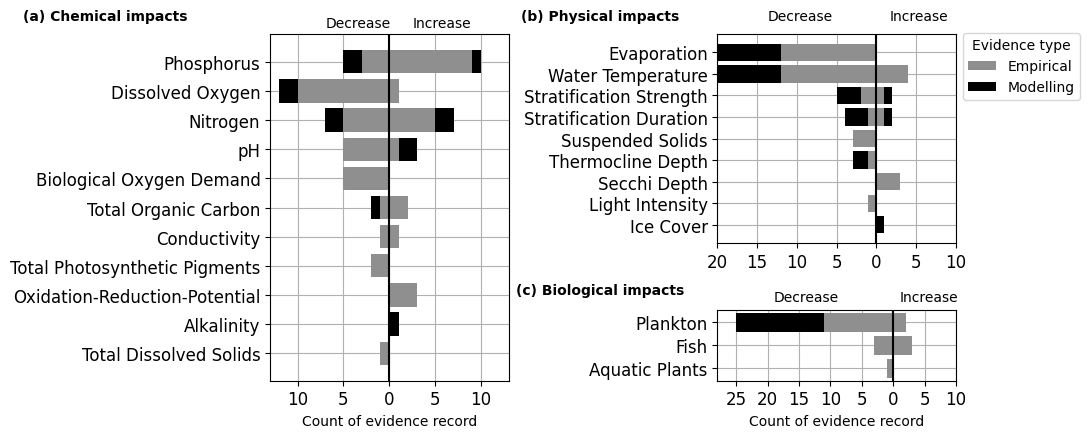

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize = (11,4.5))
ax.axis('off')
gs = GridSpec(3, 2, figure=fig)

# Chemical process
ax1 = fig.add_subplot(gs[:, 0])
class_graph = direc_imp_chem['process']
ax1.barh(direc_imp_chem['process'], direc_imp_chem['increase_empirical'], color = '#8F8F8F', label = 'Empirical')
ax1.barh(direc_imp_chem['process'], direc_imp_chem['increase_modelling'], left = direc_imp_chem['increase_empirical'], color = 'k', label = 'Modelling')

ax1.barh(direc_imp_chem['process'], direc_imp_chem['decrease_empirical'], color = '#8F8F8F')
ax1.barh(direc_imp_chem['process'], direc_imp_chem['decrease_modelling'], left = direc_imp_chem['decrease_empirical'], color = 'k')

ax1.set_xlim(-13,13)
ax1.xaxis.set_ticks(np.arange(-10, 11, 5))
ax1.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax1.get_xticks()])

ax1.text(-7, 11.2, 'Decrease', color = 'k')
ax1.text(2.5, 11.2, 'Increase', color = 'k')

ax1.set_axisbelow(True)
ax1.set_xlabel("Count of evidence record")

fig.text(0.1, 0.94, '(a) Chemical impacts', ha = 'center', size = 10, fontweight = 'bold')
ax1.axvline(0, 0, color = 'k')
ax1.grid()

# Physical process
ax2 = fig.add_subplot(gs[0:2, 1])
class_graph = direc_imp_phy['process']
ax2.barh(direc_imp_phy['process'], direc_imp_phy['increase_empirical'], color = '#8F8F8F', label = 'Empirical')
ax2.barh(direc_imp_phy['process'], direc_imp_phy['increase_modelling'], left = direc_imp_phy['increase_empirical'], color = 'k', label = 'Modelling')

ax2.barh(direc_imp_phy['process'], direc_imp_phy['decrease_empirical'], color = '#8F8F8F')
ax2.barh(direc_imp_phy['process'], direc_imp_phy['decrease_modelling'], left = direc_imp_phy['decrease_empirical'], color = 'k')

ax2.set_xlim(-20,10)
ax2.xaxis.set_ticks(np.arange(-20, 11, 5))
ax2.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax2.get_xticks()])

ax2.text(-13.7, 9.5, 'Decrease', color = 'k')
ax2.text(1.6, 9.5, 'Increase', color = 'k')

ax2.set_axisbelow(True)
ax2.legend(title = 'Evidence type', loc='upper left', bbox_to_anchor=(1, 1.04))

fig.text(0.55, 0.94, '(b) Physical impacts', ha = 'center', size = 10, fontweight = 'bold')
ax2.axvline(0, 0, color = 'k')
ax2.grid()

# Biological process
ax3 = fig.add_subplot(gs[2, 1])
class_graph = direc_imp_bio['process']
ax3.barh(direc_imp_bio['process'], direc_imp_bio['increase_empirical'], color = '#8F8F8F', label = 'Empirical')
ax3.barh(direc_imp_bio['process'], direc_imp_bio['increase_modelling'], left = direc_imp_bio['increase_empirical'], color = 'k', label = 'Modelling')

ax3.barh(direc_imp_bio['process'], direc_imp_bio['decrease_empirical'], color = '#8F8F8F')
ax3.barh(direc_imp_bio['process'], direc_imp_bio['decrease_modelling'], left = direc_imp_bio['decrease_empirical'], color = 'k')

ax3.set_xlim(-28,10)
ax3.xaxis.set_ticks(np.arange(-25, 11, 5))
ax3.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax3.get_xticks()])

ax3.text(-19, 2.95, 'Decrease', color = 'k')
ax3.text(1, 2.95, 'Increase', color = 'k')

ax3.set_axisbelow(True)
ax3.set_xlabel("Count of evidence record")

fig.text(0.55, 0.33, '(c) Biological impacts', ha = 'center', size = 10, fontweight = 'bold')
ax3.axvline(0, 0, color = 'k')
ax3.grid()

plt.tight_layout()

# Salvar o gráfico gerado
plt.savefig('direction_evidence_complete_updated_search.png', dpi = 300)

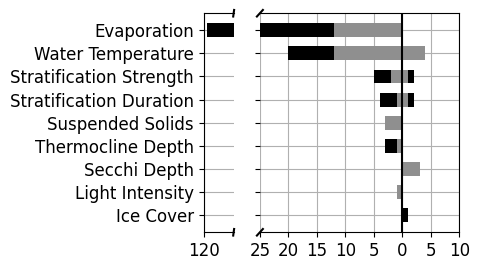

In [ ]:
# Create plot
f, (ax, ax2) = plt.subplots(1, 2, sharey=True, facecolor='w', figsize = (4.9,2.8),  gridspec_kw={'width_ratios': [0.3, 2]})

ax2.barh(direc_imp_phy['process'], direc_imp_phy['increase_empirical'], height = 0.6, color = '#8F8F8F', label = 'Empirical')
ax2.barh(direc_imp_phy['process'], direc_imp_phy['increase_modelling'], height = 0.6, left = direc_imp_phy['increase_empirical'], color = 'k', label = 'Modelling')

ax.barh(direc_imp_phy['process'], direc_imp_phy['decrease_empirical'], height = 0.6, color = '#8F8F8F')
ax.barh(direc_imp_phy['process'], direc_imp_phy['decrease_modelling'], height = 0.6, left = direc_imp_phy['decrease_empirical'], color = 'k')

ax2.barh(direc_imp_phy['process'], direc_imp_phy['decrease_empirical'], height = 0.6, color = '#8F8F8F')
ax2.barh(direc_imp_phy['process'], direc_imp_phy['decrease_modelling'], height = 0.6, left = direc_imp_phy['decrease_empirical'], color = 'k')

ax.set_xlim(-120, -110)
ax.xaxis.set_ticks(np.arange(-120, -109, 20))
ax.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax.get_xticks()])
ax2.set_xlim(-25, 10)
ax2.xaxis.set_ticks(np.arange(-25, 11, 5))
ax2.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax2.get_xticks()])

ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_left()

# Clip x axis to improve visualization
d = .015 # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax.transAxes, color = 'k', clip_on = False)
ax.plot((1-d, 1+d), (-d, +d), **kwargs)
ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((-d, +d), (-d, +d), **kwargs)

# ax2.text(-19, 9.8, 'Decrease', color = 'k')
# ax2.text(4.5, 9.8, 'Increase', color = 'k')

ax.set_axisbelow(True)
ax2.set_axisbelow(True)
# ax2.set_xlabel("Count of evidence record")

ax2.axvline(0, 0, color = 'k')
ax.grid()
ax2.grid()

# ax2.legend(title = 'Evidence type', loc='upper left', bbox_to_anchor=(1, 1.02))
# ax2.legend(title = 'Evidence type', loc='upper right')

# ax.margins(y=0.03, x = 0.03)

plt.tight_layout()

# Salvar o gráfico gerado
plt.savefig('physical_direction_updated_search.jpeg', dpi=300, transparent = True)

# Direction of impact - Categories (CHE - PHY - BIO)

In [ ]:
evidence_clean = direction_imp[direction_imp['total'] > 4]
evidence_clean = evidence_clean.sort_values(by = 'class', ascending=False)
evidence_clean

,process,class,increase_modelling,decrease_modelling,varies_modelling,no_change_modelling,increase_empirical,decrease_empirical,varies_empirical,no_change_empirical,total
7,Suspended Solids,Physical,0,0,NaN,NaN,0,-3,NaN,2.0,5
5,Stratification Duration,Physical,1,-3,NaN,NaN,1,-1,NaN,NaN,6
6,Stratification Strength,Physical,1,-3,NaN,NaN,1,-2,NaN,NaN,7
9,Water Temperature,Physical,3,-8,NaN,NaN,4,-12,2.0,3.0,32
0,Evaporation,Physical,0,-107,NaN,NaN,0,-12,NaN,NaN,119
11,Biological Oxygen Demand,Chemical,0,0,NaN,NaN,0,-5,NaN,1.0,6
17,pH,Chemical,2,0,NaN,NaN,1,-5,NaN,4.0,12
15,Nitrogen,Chemical,2,-2,NaN,NaN,5,-5,NaN,3.0,17
14,Dissolved Oxygen,Chemical,0,-2,NaN,NaN,1,-10,1.0,4.0,18
18,Phosphorus,Chemical,1,-2,NaN,NaN,9,-3,NaN,5.0,20


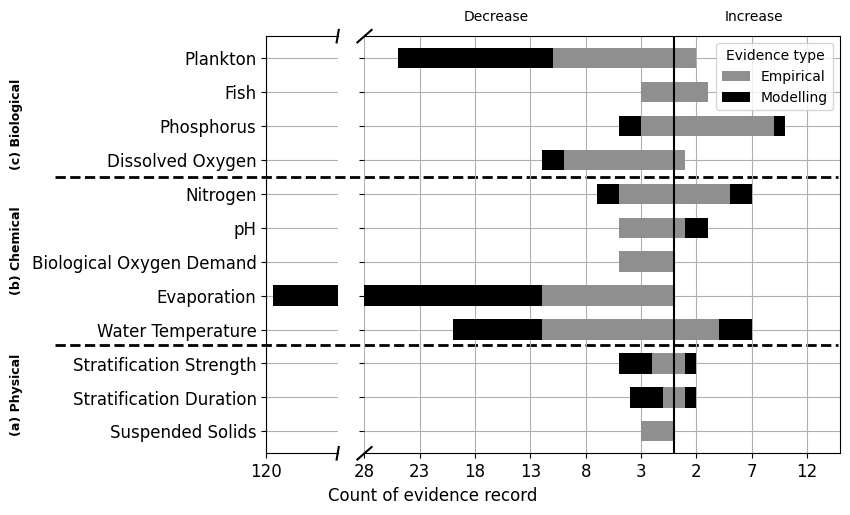

In [ ]:
# Create plot
f, (ax, ax2) = plt.subplots(1, 2, sharey=True, facecolor='w', figsize = (9,5),  gridspec_kw={'width_ratios': [0.3, 2]})

ax2.barh(evidence_clean['process'], evidence_clean['increase_empirical'], height = 0.6, color = '#8F8F8F', label = 'Empirical')
ax2.barh(evidence_clean['process'], evidence_clean['increase_modelling'], height = 0.6, left = evidence_clean['increase_empirical'], color = 'k', label = 'Modelling')

ax.barh(evidence_clean['process'], evidence_clean['decrease_empirical'], height = 0.6, color = '#8F8F8F')
ax.barh(evidence_clean['process'], evidence_clean['decrease_modelling'], height = 0.6, left = evidence_clean['decrease_empirical'], color = 'k')

ax2.barh(evidence_clean['process'], evidence_clean['decrease_empirical'], height = 0.6, color = '#8F8F8F')
ax2.barh(evidence_clean['process'], evidence_clean['decrease_modelling'], height = 0.6, left = evidence_clean['decrease_empirical'], color = 'k')

ax.set_xlim(-120, -110)
ax.xaxis.set_ticks(np.arange(-120, -109, 20))
ax.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax.get_xticks()])
ax2.set_xlim(-25, 15)
ax2.xaxis.set_ticks(np.arange(-28, 16, 5))
ax2.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax2.get_xticks()])

ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_left()

# Clip x axis to improve visualization
d = .015 # how big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax.transAxes, color = 'k', clip_on = False)
ax.plot((1-d, 1+d), (-d, +d), **kwargs)
ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((-d, +d), (-d, +d), **kwargs)

ax2.text(-19, 12.1, 'Decrease', color = 'k')
ax2.text(4.5, 12.1, 'Increase', color = 'k')

ax.set_axisbelow(True)
ax2.set_axisbelow(True)
# ax2.set_xlabel("Count of evidence record")

ax2.axvline(0, 0, color = 'k')
ax.grid()
ax2.grid()

ax.axhline(y = 7.5, xmin = -1, xmax = -1, c = "k", linewidth = 2, linestyle = '--', zorder = 0, clip_on = False)
ax2.axhline(y = 7.5, xmin = -0.65, xmax = 0.995, c = "k", linewidth = 2, linestyle = '--', zorder = 0, clip_on = False)

ax.axhline(y = 2.53, xmin = -1, xmax = -1, c = "k", linewidth = 2, linestyle = '--', zorder = 0, clip_on = False)
ax2.axhline(y = 2.53, xmin = -0.65, xmax = 0.995, c = "k", linewidth = 2, linestyle = '--', zorder = 0, clip_on = False)

ax.text(-155, -0.05, '(a) Physical', ha = 'center', size = 9, rotation = 90, fontweight = 'bold')
# ax.text(-87, -0.45, 'Biological', ha = 'center', size = 10, rotation = 90, fontweight = 'bold')
ax.text(-155, 4.1, '(b) Chemical', ha = 'center', size = 9, rotation = 90, fontweight = 'bold')
ax.text(-155, 7.8, '(c) Biological', ha = 'center', size = 9, rotation = 90, fontweight = 'bold')

# ax2.legend(title = 'Evidence type', loc='upper left', bbox_to_anchor=(1, 1.02))
ax2.legend(title = 'Evidence type', loc='upper right')

f.text(0.53, -0.01, "Count of evidence record", ha = 'center', size = 12)

ax.margins(y=0.03, x = 0.03)

plt.tight_layout()

# Salvar o gráfico gerado
plt.savefig('direction_evidence_morethan5_updated_search.jpeg', dpi=300, bbox_inches='tight')

# Frequency analysis - Lakes constituents and processes

In [ ]:
# Import files
processes_frequency_count = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/PhD/review/files/processes_frequency_count_updated_search.csv')
processes_frequency_count.head()

,process,yes,no,class
0,Evaporation,56,18,Physical
1,Temperature,23,51,Physical
2,Plankton,16,58,Biological
3,Dissolved Oxygen,16,58,Chemical
4,Nutrients,14,60,Chemical


In [ ]:
# Create subset dataframes following classes
freq_physical = processes_frequency_count.loc[processes_frequency_count['class'] == 'Physical']
freq_chemical = processes_frequency_count.loc[processes_frequency_count['class'] == 'Chemical']
freq_biological = processes_frequency_count.loc[processes_frequency_count['class'] == 'Biological']

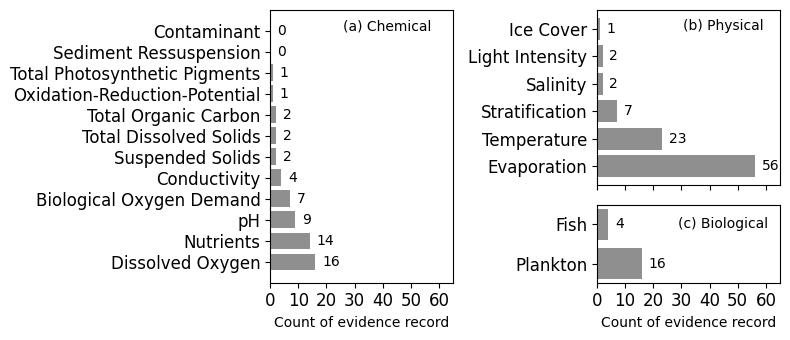

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize = (8,3.5))
ax.axis('off')
gs = GridSpec(3, 2, figure=fig)

# Chemical process
ax1 = fig.add_subplot(gs[:, 0])
class_graph = freq_chemical['process']
hbars = ax1.barh(freq_chemical['process'], freq_chemical['yes'], color = '#8F8F8F', label = 'Chemical')

ax1.set_xlim(0,65)
ax1.xaxis.set_ticks(np.arange(0, 66, 10))
ax1.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax1.get_xticks()])

ax1.set_axisbelow(True)
ax1.set_xlabel("Count of evidence record")

fig.text(0.49, 0.9, '(a) Chemical', ha = 'center', size = 10)

ax1.bar_label(hbars, padding = 5)

# Physical process
ax2 = fig.add_subplot(gs[0:2, 1])
class_graph = freq_physical['process']
hbars = ax2.barh(freq_physical['process'], freq_physical['yes'], color = '#8F8F8F', label = 'Physical')

ax2.set_xlim(0,65)
ax2.xaxis.set_ticks(np.arange(0, 66, 10))
ax2.set_xticklabels([])
# ax2.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax2.get_xticks()])

ax2.set_axisbelow(True)

fig.text(0.91, 0.9, '(b) Physical', ha = 'center', size = 10)

ax2.bar_label(hbars, padding = 5)

# Biological process
ax3 = fig.add_subplot(gs[2, 1])
class_graph = freq_biological['process']
hbars = ax3.barh(freq_biological['process'], freq_biological['yes'], color = '#8F8F8F', label = 'Biological')

ax3.set_xlim(0,65)
ax3.xaxis.set_ticks(np.arange(0, 66, 10))
ax3.set_xticklabels(["{0:.0f}".format(abs(x)) for x in ax3.get_xticks()])

ax3.set_axisbelow(True)
ax3.set_xlabel("Count of evidence record")

fig.text(0.91, 0.335, '(c) Biological', ha = 'center', size = 10)

ax3.bar_label(hbars, padding = 5)

plt.tight_layout()

# Salvar o gráfico gerado
plt.savefig('processes_frequency_count_updated_search.jpeg', dpi = 300)

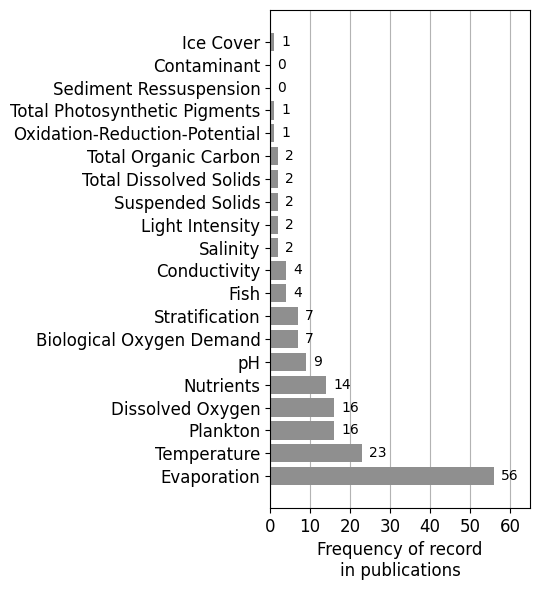

In [ ]:
# Plot
# Create a circle at the center of the plot
fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (5.5,6))

# Increase and decrease side
hbars = ax.barh(processes_frequency_count['process'], processes_frequency_count['yes'], color = '#8F8F8F')

ax.set_xlim(0,65)
ax.xaxis.set_ticks(np.arange(0, 66, 10))

ax.bar_label(hbars, padding = 5)

ax.set_axisbelow(True)
ax.set_xlabel("Frequency of record\nin publications", fontsize = 12)

ax.grid(which = 'major', color='#B3B3B3', axis = 'x', linestyle = '-')

plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)

# ax.minorticks_on()

plt.tight_layout()

# Salvar o gráfico gerado
plt.savefig('joined_processes_frequency_count_updated_search.jpeg', dpi=300)